# Assignment1: Python for AI

## Task 4

In [1]:
# Five basic Python data types

name = "Divine"          # str: represents text
age = 22                 # int: represents a whole number
accuracy = 0.85          # float: represents a decimal number
is_trained = True        # bool: represents True or False
result = None            # None: represents the absence of a value

print(name, type(name))
print(age, type(age))
print(accuracy, type(accuracy))
print(is_trained, type(is_trained))
print(result, type(result))

Divine <class 'str'>
22 <class 'int'>
0.85 <class 'float'>
True <class 'bool'>
None <class 'NoneType'>


In [2]:
# Casting converts a value from one data type to another.

score_text = "85.7"
score_float = float(score_text)

temperature = 25.9
temperature_int = int(temperature)  # The decimal part is truncated, not rounded.

print(score_float, type(score_float))
print(temperature_int, type(temperature_int))

85.7 <class 'float'>
25 <class 'int'>


In [3]:
# An f-string allows us to insert variables directly into a formatted sentence.

model_name = "AI Classifier"
accuracy = 0.87
epochs = 10

print(f"{model_name} achieved {accuracy:.1%} accuracy after {epochs} epochs.")

AI Classifier achieved 87.0% accuracy after 10 epochs.


In [4]:
# The conditional evaluates model accuracy and latency to decide what to do.

accuracy = 0.88
latency = 120  # milliseconds

if accuracy >= 0.85 and latency <= 200:
    decision = "ship it"
elif latency > 200:
    decision = "too slow"
else:
    decision = "keep training"

print(f"Decision: {decision}")

Decision: ship it


In [6]:
# enumerate() gives us both the position and the score while looping.

scores = [0.62, 0.71, 0.79, 0.84]

for epoch, score in enumerate(scores, start=1):
    print(f"epoch {epoch}: {score}")

epoch 1: 0.62
epoch 2: 0.71
epoch 3: 0.79
epoch 4: 0.84


In [7]:
# List: suitable for an ordered collection of scores that may change.
scores = [0.72, 0.81, 0.76, 0.90]

# Tuple: suitable for fixed information that should not be changed.
model_info = ("AI Classifier", "v1.0")

# Dictionary: suitable for storing data as key-value pairs.
student = {
    "name": "Divine",
    "course": "Python for AI"
}

# Set: suitable for storing unique values without duplicates.
subjects = {"Python", "AI", "Python", "Data"}

print("List:", scores)
print("Tuple:", model_info)
print("Dictionary:", student)
print("Set:", subjects)

List: [0.72, 0.81, 0.76, 0.9]
Tuple: ('AI Classifier', 'v1.0')
Dictionary: {'name': 'Divine', 'course': 'Python for AI'}
Set: {'AI', 'Python', 'Data'}


In [8]:
# List comprehension with a filter: keeps only scores that are at least 0.8.

scores = [0.65, 0.82, 0.91, 0.74, 0.88]

high_scores = [score for score in scores if score >= 0.8]

print("High scores:", high_scores)

High scores: [0.82, 0.91, 0.88]


In [9]:
# Dictionary comprehension creates a dictionary of each epoch and its score.

scores = [0.65, 0.82, 0.91, 0.88]

epoch_scores = {
    epoch: score
    for epoch, score in enumerate(scores, start=1)
}

print("Epoch scores:", epoch_scores)

Epoch scores: {1: 0.65, 2: 0.82, 3: 0.91, 4: 0.88}


## Task 3

In [10]:
def normalise(values, minimum=None, maximum=None):
    """
    Scale a list of numbers into the 0–1 range.

    Args:
        values: A list of numeric values to normalise.
        minimum: Optional lower bound. If None, the minimum value is used.
        maximum: Optional upper bound. If None, the maximum value is used.

    Returns:
        A list of normalised values between 0 and 1.
        If all values are identical, returns a list of 0.0 values.
    """
    if not values:
        return []

    if minimum is None:
        minimum = min(values)

    if maximum is None:
        maximum = max(values)

    # Prevent division by zero when minimum and maximum are equal.
    if minimum == maximum:
        return [0.0 for _ in values]

    return [(value - minimum) / (maximum - minimum) for value in values]

In [11]:
scores = [12, 18, 25, 40]

normalised_scores = normalise(scores)

print("Original:", scores)
print("Normalised:", normalised_scores)

Original: [12, 18, 25, 40]
Normalised: [0.0, 0.21428571428571427, 0.4642857142857143, 1.0]


In [12]:
identical_values = [5, 5, 5, 5]

print("Identical values:", identical_values)
print("Normalised:", normalise(identical_values))

Identical values: [5, 5, 5, 5]
Normalised: [0.0, 0.0, 0.0, 0.0]


In [13]:
def summarise_scores(scores):
    """
    Calculate summary statistics for a list of scores.

    Args:
        scores: A list of numeric scores.

    Returns:
        A dictionary containing count, mean, minimum, maximum,
        and the number of scores greater than or equal to 0.8.
        For an empty list, numerical summary values are returned as 0.
    """
    if not scores:
        return {
            "count": 0,
            "mean": 0.0,
            "minimum": 0.0,
            "maximum": 0.0,
            "above_threshold": 0
        }

    return {
        "count": len(scores),
        "mean": sum(scores) / len(scores),
        "minimum": min(scores),
        "maximum": max(scores),
        "above_threshold": sum(score >= 0.8 for score in scores)
    }

In [14]:
scores_1 = [0.65, 0.82, 0.91, 0.74, 0.88]

summary_1 = summarise_scores(scores_1)

print(summary_1)

{'count': 5, 'mean': 0.8, 'minimum': 0.65, 'maximum': 0.91, 'above_threshold': 3}


In [15]:
scores_2 = [0.45, 0.60, 0.72, 0.79]

summary_2 = summarise_scores(scores_2)

print(summary_2)

{'count': 4, 'mean': 0.64, 'minimum': 0.45, 'maximum': 0.79, 'above_threshold': 0}


In [16]:
def safe_divide(numerator, denominator, default=0.0):
    """
    Safely divide two numbers.

    Args:
        numerator: The number to be divided.
        denominator: The number to divide by.
        default: The value returned if division cannot be performed.

    Returns:
        The division result, or default if the denominator is zero
        or either input is not numeric.
    """
    try:
        if not isinstance(numerator, (int, float)) or isinstance(numerator, bool):
            raise TypeError("Numerator must be numeric.")

        if not isinstance(denominator, (int, float)) or isinstance(denominator, bool):
            raise TypeError("Denominator must be numeric.")

        return numerator / denominator

    except (ZeroDivisionError, TypeError):
        return default

In [17]:
print("Normal case:", safe_divide(10, 2))

Normal case: 5.0


In [18]:
print("Divide by zero:", safe_divide(10, 0))

Divide by zero: 0.0


In [19]:
print("Text input:", safe_divide("10", 2))

Text input: 0.0


# Task 4: Numpy and Pandas



In [20]:
import numpy as np

# Create a 1-D NumPy array containing model scores.
scores_array = np.array([65, 72, 80, 85, 90, 95])

print("Scores:", scores_array)
print("Mean:", scores_array.mean())
print("Standard deviation:", scores_array.std())
print("Minimum:", scores_array.min())
print("Maximum:", scores_array.max())

Scores: [65 72 80 85 90 95]
Mean: 81.16666666666667
Standard deviation: 10.25372561018135
Minimum: 65
Maximum: 95


In [21]:
# Create a 2-D NumPy array with 3 rows and 4 columns.
data_2d = np.array([
    [10, 20, 30, 40],
    [15, 25, 35, 45],
    [20, 30, 40, 50]
])

print("2-D array:")
print(data_2d)

print("Original shape:", data_2d.shape)
print("Transpose shape:", data_2d.T.shape)

2-D array:
[[10 20 30 40]
 [15 25 35 45]
 [20 30 40 50]]
Original shape: (3, 4)
Transpose shape: (4, 3)


In [22]:
# Calculate the mean of each column.
column_means = data_2d.mean(axis=0)

# Subtract each column mean from the corresponding column.
centred_data = data_2d - column_means

print("Column means:")
print(column_means)

print("\nData after subtracting column means:")
print(centred_data)

Column means:
[15. 25. 35. 45.]

Data after subtracting column means:
[[-5. -5. -5. -5.]
 [ 0.  0.  0.  0.]
 [ 5.  5.  5.  5.]]


In [25]:
import pandas as pd

# Create a DataFrame containing student/model training information.
df = pd.DataFrame({
    "Name": ["Divine", "Kamili", "Bria", "Claudine", "Dave", "Elie"],
    "Score": [0.85, 0.72, 0.91, 0.68, 0.79, 0.88],
    "Epochs": [10, 12, 8, 15, 11, 9],
    "Status": ["Pass", "Pass", "Pass", "Fail", "Pass", "Pass"],
    "Comment": ["Good", "Average", None, "Needs work", "Good", "Excellent"]
})

print(df)

       Name  Score  Epochs Status     Comment
0    Divine   0.85      10   Pass        Good
1    Kamili   0.72      12   Pass     Average
2      Bria   0.91       8   Pass         NaN
3  Claudine   0.68      15   Fail  Needs work
4      Dave   0.79      11   Pass        Good
5      Elie   0.88       9   Pass   Excellent


In [26]:
# Display information about columns, data types, and non-null values.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Name     6 non-null      str    
 1   Score    6 non-null      float64
 2   Epochs   6 non-null      int64  
 3   Status   6 non-null      str    
 4   Comment  5 non-null      str    
dtypes: float64(1), int64(1), str(3)
memory usage: 372.0 bytes


In [27]:
# Display statistical summaries for numerical columns.
df.describe()

,Score,Epochs
count,6.000000,6.000000
mean,0.805000,10.833333
std,0.091378,2.483277
min,0.680000,8.000000
25%,0.737500,9.250000
50%,0.820000,10.500000
75%,0.872500,11.750000
max,0.910000,15.000000


In [28]:
# Count missing values in each column.
print(df.isna().sum())

Name       0
Score      0
Epochs     0
Status     0
Comment    1
dtype: int64


In [29]:
# Filter students with scores of at least 0.80 and sort by score.
high_scores = df[df["Score"] >= 0.80].sort_values(
    by="Score",
    ascending=False
)

print(high_scores)

     Name  Score  Epochs Status    Comment
2    Bria   0.91       8   Pass        NaN
5    Elie   0.88       9   Pass  Excellent
0  Divine   0.85      10   Pass       Good


In [33]:
# Filter students with scores of at least 0.80 and sort by score.
high_scores = df[df["Score"] >= 0.80].sort_values(
    by="Score",
    ascending=False
)

print(high_scores)

     Name  Score  Epochs Status    Comment
2    Bria   0.91       8   Pass        NaN
5    Elie   0.88       9   Pass  Excellent
0  Divine   0.85      10   Pass       Good


In [34]:
# Create a boolean column indicating whether the score meets the 0.80 threshold.
df["Pass_Flag"] = df["Score"] >= 0.80

print(df)

       Name  Score  Epochs Status     Comment  Pass_Flag
0    Divine   0.85      10   Pass        Good       True
1    Kamili   0.72      12   Pass     Average      False
2      Bria   0.91       8   Pass         NaN       True
3  Claudine   0.68      15   Fail  Needs work      False
4      Dave   0.79      11   Pass        Good      False
5      Elie   0.88       9   Pass   Excellent       True


### Meaning of the Missing Values

The missing value in the `Comment` column could mean that no comment was recorded for that student or that the information was unavailable during data collection. In real-world data, I would investigate why the value is missing before deciding whether to replace it, remove the row, or leave it as missing.

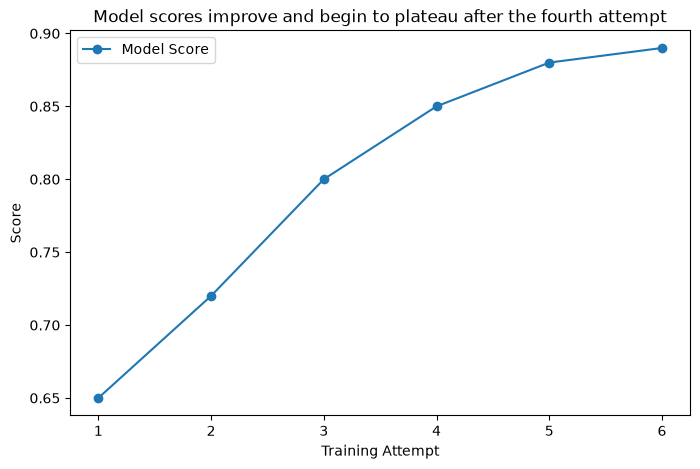

In [39]:
import matplotlib.pyplot as plt

# Scores from different training attempts
attempts = [1, 2, 3, 4, 5, 6]
scores = [0.65, 0.72, 0.80, 0.85, 0.88, 0.89]

plt.figure(figsize=(8, 5))

plt.plot(attempts, scores, marker="o", label="Model Score")

plt.xlabel("Training Attempt")
plt.ylabel("Score")
plt.title("Model scores improve and begin to plateau after the fourth attempt")

plt.legend()

plt.savefig("../reports/day01_chart.png", dpi=150, bbox_inches="tight")

plt.show()

In [41]:
import os

print(os.path.exists("../reports/day01_chart.png"))
print(os.path.abspath("../reports/day01_chart.png"))

True
c:\Users\NV TECHNOLOGIES LTD\OneDrive\Documents\KLab\reports\day01_chart.png


In [38]:
import os

print("Current working directory:")
print(os.getcwd())

print("\nFiles and folders here:")
print(os.listdir())

Current working directory:
c:\Users\NV TECHNOLOGIES LTD\OneDrive\Documents\KLab\notebooks

Files and folders here:
['.gitkeep', 'assignment1.ipynb', 'assignment2.ipynb', 'assignment3.ipynb']
